# Examen Supletorio ITQ Machine Elerarning
**Nombre:** Evelyn Lascano<br>
**Fecha:** 11/02/2026

In [25]:
#Importo las librerias que necesito
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 01 - 1.25pt
- Crear un array de NumPy de dimensiones 5x5, con números enteros aleatorios en el rango [-40, 40]
- Hacer los siguientes reemplazos en orden
    - Reemplazar todos los valores multiplos de 3 por 1
    - Reemplazar todos los valores pares positivos por 0
    - Reemplazar todos los valores pares negativos por Nan
- Averiguar cuantos elementos tienen Nan por fila

In [26]:
# Creo el array 5x5 
array = np.random.randint(-40, 40, size=(5, 5)).astype(float) # Usamo float para poder insertar NaN

# Reemplazo múltiplos de 3 por 1
array[array % 3 == 0] = 1

# Reemplazo pares positivos por 0
array[(array % 2 == 0) & (array > 0)] = 0

# Reemplazo pares negativos por Nan
array[(array % 2 == 0) & (array < 0)] = np.nan

# Verifico cuántos elementos tienen Nan por fila
nan_por_fila = np.isnan(array).sum(axis=1)

print(array)
print("NaN por fila:", nan_por_fila)

[[  1.   1.   1.  31.  23.]
 [  1.   1.  19.   0.   5.]
 [  1.   0.  nan   0.   1.]
 [  1.   1. -17. -29.   1.]
 [-19.  nan   1.  25.   0.]]
NaN por fila: [0 0 1 0 1]


## 02 - 1.25pt
- Escribe una función que cada vez que se le invoque devuelva el factorial del siguiente número entero, empezando por 1, hasta cualquier número infinito

In [27]:
#Defino la funcion fact_gen
def fact_gen():
    n = 1
    f = 1
#El while revisa esto mientras sea verdad
    while True:
        yield f
        n += 1
        f *= n

# Al ejecutar la celda de test , el assert debe pasar sin errores.

In [28]:
# Test Use Case
expected_output = [1, 2, 6, 24, 120, 720, 5040, 40320]

g = fact_gen()  # This calls your function named fact_gen
output = [next(g) for n in range(len(expected_output))]

display(expected_output)
display(output)

assert(expected_output == output) # This will fail if the list is wrong

[1, 2, 6, 24, 120, 720, 5040, 40320]

[1, 2, 6, 24, 120, 720, 5040, 40320]

## 03 - 1.25pt
- Escribir una función que reciba un Dataframe, en la columna "name" convierta el primer carácter de cada nombre a mayúsculas.

In [29]:
#Creo la funcion con el comando capitalize name 
def capitalize_name(df):
#Aqui hago que con el comando str.capotalize convierta el primer carácter de cada nombre a mayúsculas
    df['name'] = df['name'].str.capitalize()
#Retorno con resultado
    return df

In [30]:
# Test Use Case
dataframe = pd.DataFrame({
    'name': ['tamayo','tanjiro','inosuke', 'zenitsu', 'nezuko'],
    'date_of_birth ': ['13/01/2002','18/03/1999','21/11/1998','10/10/2002','05/04/1997'],
    'age': [18.5, 21.2, 22.5, 22, 23]
})

expected_output = pd.DataFrame({
    'name': ['Tamayo', 'Tanjiro', 'Inosuke', 'Zenitsu', 'Nezuko'],
    'date_of_birth ': ['13/01/2002','18/03/1999','21/11/1998','10/10/2002','05/04/1997'],
    'age': [18.5, 21.2, 22.5, 22, 23]
})

output = capitalize_name(dataframe) # This calls your function capitalize_name

display(expected_output)
display(output)

assert(expected_output.equals(output)) # This will fail if result is not as expected

,name,date_of_birth,age
0,Tamayo,13/01/2002,18.5
1,Tanjiro,18/03/1999,21.2
2,Inosuke,21/11/1998,22.5
3,Zenitsu,10/10/2002,22.0
4,Nezuko,05/04/1997,23.0


,name,date_of_birth,age
0,Tamayo,13/01/2002,18.5
1,Tanjiro,18/03/1999,21.2
2,Inosuke,21/11/1998,22.5
3,Zenitsu,10/10/2002,22.0
4,Nezuko,05/04/1997,23.0


## 04 - 1.25pt
- 200 personas hacen una review de una película, dándole una puntuación de 0.0 a 5.0 a dicha película
- Crear una lista aleatoria con las posibles puntuaciones, es decir, 200 puntuaciones entre 0.0 y 5.0
- Discretizar dichas puntuaciones en 4 categorias [muy mala, mala, buena, excelente], los límites de cada categoría son a libre elección
- Discretizar dichas puntuaciones en 5 categorías distribuidas con rangos homogéneos (similar cantidad de valores en cada categoría)
- Mostrar las categorías creadas y cuantos elementos hay en cada una de ellas

In [31]:
#Creo 200 puntuaciones aleatorias
puntuacion = np.random.uniform(0.0, 5.0, 200)
df = pd.DataFrame(puntuacion, columns=['score'])

#Discretizo (pd.cut para límites fijos y pd.qcut para rangos iguales)
categoria_numeros = [0, 1.25, 2.5, 3.75, 5.0]
categoria_letras = ['Muy mala', 'Mala', 'Buena', 'Excelente']
df['Categorías'] = pd.cut(df['score'], bins=categoria_numeros, labels=categoria_letras, include_lowest=True)

#Rangos homogéneos para la misma cantidad de personas
df['cat_homogenea'] = pd.qcut(df['score'], q=5)

#Muestro el conteo usando value_counts
print(df['Categorías'].value_counts().sort_index())


Categorías
Muy mala     51
Mala         44
Buena        49
Excelente    56
Name: count, dtype: int64


## 05 - 5pt

El conjunto de datos "estaciones_bici.csv" (fichero disponible adjunto a la actividad) proviene de una descarga de datos del servicio web de la empresa municipal Valenbici, dedicada al alquiler de bicicletas en Valencia.

Los datos recabados de este servicio web son de mediciones cada 10 minutos de las estaciones:

https://valencia.opendatasoft.com/explore/dataset/valenbisi-disponibilitat-valenbisi-dsiponibilidad/information/

Cada estación está compuesta por un número variable de bornetas (total) donde se pueden anclar las bicicletas. Los datos obtenidos de cada estación (registros) refleja el número de bornetas libres (free) y el número de bicicletas disponibles (available).

#### Columnas para trabajar:
- station: id de la estación
- total: número total de bornetas
- updated: timestamp del estado en de bicis en la estación
- available: número de bicis disponibles

#### Preguntas
1. Carga de datos de csv (estaciones_bici.csv) en un DataFrame
2. ¿Cuál es el rango temporal del dataset? Obtención del número de estaciones que tienen un total de 30 bornetas
3. Número de estación con la media más alta de bicis disponibles
4. Realizar el histograma de bicis disponibles de la estación del punto anterior
5. Realizar gráfica con  la línea temporal de bicis disponibles de la estación del punto anterior. Pista, es necesario cambiar el índice a uno tipo fecha

In [38]:
# 1. Carga de datos de csv (estaciones_bici.csv) en un DataFrame
df = pd.read_csv('estaciones_bici.csv')

In [39]:
#En esta parte voy a limpiar ya que el dataset al querer usarlo me da error y es por las ; o espacios
print(df.columns.tolist())

#Cargo especificando que el separador es ';' 
df = pd.read_csv('estaciones_bici.csv', sep=';')

#Elimino la primera columna proqueaparece vacía y tambien limpio los espacios en blanco de los nombres
df.columns = df.columns.str.replace(';', '').str.strip()

#Verifico que ahora 'updated' sea una columna real ya que al correr antes me daba error y era por la manera en que estaban separadas
print("Columnas detectadas:", df.columns.tolist())

[';_id;available;connected;download_date;station;free;open;ticket;total;updated']
Columnas detectadas: ['Unnamed: 0', '_id', 'available', 'connected', 'download_date', 'station', 'free', 'open', 'ticket', 'total', 'updated']


In [40]:
# 2. Rango temporal del dataset
#Convierto la columna 'updated' a datetime para poder calcular el rango
df['updated'] = pd.to_datetime(df['updated'])
rango_min = df['updated'].min()
rango_max = df['updated'].max()
print(f"Rango temporal: desde {rango_min} hasta {rango_max}")

Rango temporal: desde 2019-02-10 17:21:13 hasta 2019-02-11 23:42:16


In [41]:
# 2.b Obtencion del numero de estaciones que tienen un total de 30 bornetas
# Uso filtrado y el método unique() para no contar registros repetidos de la misma estación
estaciones_30 = df[df['total'] == 30]['station'].nunique()
print(f"Número de estaciones con 30 bornetas: {estaciones_30}")

Número de estaciones con 30 bornetas: 11


In [42]:
# 3. Número de estación con la media más alta de bicis disponibles
#Agrupo por estación y calculamos la media de 'available'
media_por_estacion = df.groupby('station')['available'].mean()
estacion_top = media_por_estacion.idxmax()
valor_media_top = media_por_estacion.max()
print(f"Estación con media más alta: {estacion_top} (Media: {valor_media_top:.2f})")

Estación con media más alta: 50 (Media: 31.26)


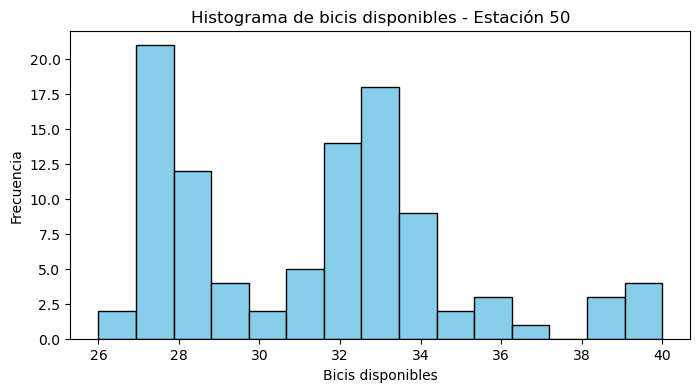

In [43]:
# 4. Realizar el histograma de bicis disponibles de la estación del punto anterior
#Se filtra los datos de esa estación específica
df_top = df[df['station'] == estacion_top]

#Crea una nueva figura y le doy el tamaño
plt.figure(figsize=(8, 4))
plt.hist(df_top['available'], bins=15, color='skyblue', edgecolor='black') 
#Despues le doy etiquetas y nombres a los ejes
plt.title(f"Histograma de bicis disponibles - Estación {estacion_top}")
plt.xlabel("Bicis disponibles")
plt.ylabel("Frecuencia")
plt.show()

In [48]:
# 5. Realizar gráfica con  la línea temporal de bicis disponibles de la estación del punto anterior. Pista, es necesario cambiar el tipo de dato a uno tipo fecha

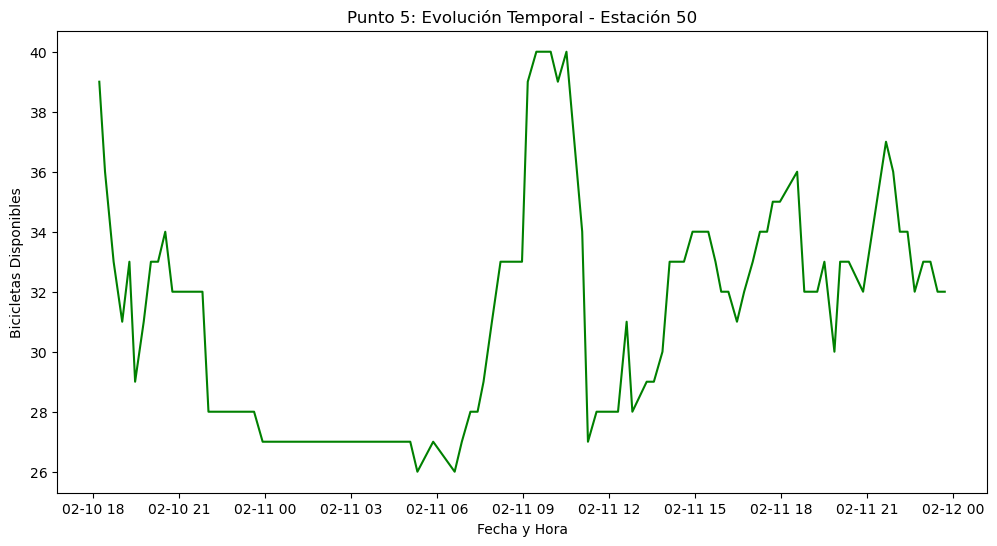

In [47]:
# La pista que no da es  cambiar el índice a tipo fecha y ordenar
df_temporal = df_estacion.set_index('updated').sort_index()

#Aqui utilizo plt para darle las instrucciones de como va a graficar 
#Crea una nueva figura y le doy el tamaño
plt.figure(figsize=(12, 6))

#Crear gráficos de líneas; con el df_temporal['available'] este es el primer argumento y representa los datos del eje Y,el color green para el color de la linea y el linewisht para el grosor
plt.plot(df_temporal['available'], color='green', linewidth=1.5)

#Despues le doy etiquetas y nombres a los ejes
plt.title(f"Punto 5: Evolución Temporal - Estación {estacion_top}")
plt.xlabel("Fecha y Hora")
plt.ylabel("Bicicletas Disponibles")
plt.show()